In [1]:
# Imports
import ROOT
import array

from tools import scale_out as so

from emm import data as dat
from emm import fitting
from emm import models
from emm import signal_injection as si

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT.gErrorIgnoreLevel = ROOT.kWarning

fit_options = [
    ROOT.RooFit.PrintLevel(-1),
]

Welcome to JupyROOT 6.30/04


In [2]:
# Load data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = dat.get_diphoton_data(tree=True)
diphoton_data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = diphoton_data.numEntries()
data_mean = diphoton_data.mean(x)
print(f"Data mean: {data_mean}")

Data mean: 676.7652379849756


In [3]:
# Set up models
# toy_models = [
#     models.f1(x),
#     # models.f2(x),
#     # models.f3(x),
#     # models.f4(x),
# ]
toy_model = models.f1(x)

model_primitives = [
    models.ModelPrimitive(models.f1),
    models.ModelPrimitive(models.f2),
    models.ModelPrimitive(models.f3),
    models.ModelPrimitive(models.f4),
]
for k in range(2, 6):
    model_primitives.append(
        models.ModelPrimitive(
            models.ExponentialMixtureModel,
            k, data_mean=data_mean,
            name=f"ExponentialMixture-{k}"
        )
    )

# Fit toy models to data
# for toy_model in toy_models:
#     print(f"Fitting toy model: {toy_model.name}")
#     toy_model.pdf.fitTo(diphoton_data)
toy_model.pdf.fitTo(diphoton_data, *fit_options)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization


In [4]:
# Configuration
signal_points = [
    (500, 20),
    (550, 25),
    (600, 30),
    (800, 35),
    (1000, 40),
    (1200, 45),
    (1400, 50),
    (1600, 55),
    (1800, 60),
    (2000, 65),
]

# Fit configuration
n_restarts = 30
n_retries = 10

# Injection configuration
n_seeds = 20
n_toys_per_seed = 50
c_values = [0, 1, 2, 3, 5]

# Test overrides
# n_seeds = 2
# n_toys_per_seed = 1
# c_values = [0, 5]

default_seed = 123456

# Use a distinct seed stream for injected toys so they are not identical to the
# background-only calibration toys (still fully reproducible).
np.random.seed(default_seed + 1)
seeds = np.random.randint(0, 10000, size=n_seeds)

In [5]:
# Step 1: Calibrate sigma_s
import os
import pickle

remake_calibration=False
# remake_calibration=True

# Calibration configuration
calibration_n_seeds = 20
calibration_n_toys_per_seed = 20

calibration_seeds = np.random.randint(0, 10000, size=calibration_n_seeds)

calibration_file = f"{si.signal_injection_cache}/calibration_results.pkl"
if not os.path.exists(calibration_file) or remake_calibration:
    calibration_model_primitives = [models.ModelPrimitive(type(toy_model))]
    tasks = []
    for seed in calibration_seeds:
        for signal_point in signal_points:
            task = so.Task(
                si.run_signal_injection_fits,
                x,
                toy_model,
                calibration_model_primitives,
                0,
                0,
                seed,
                calibration_n_toys_per_seed,
                n,
                signal_point,
                n_restarts,
                n_retries,
                fit_options=fit_options,
                print_level=1,
                save_as=None,
            )
            tasks.append(task)

    calibration_results = [
        result
        for task_results in so.run_tasks(tasks)
        for result in task_results
    ]
    calibration_df = pd.DataFrame(calibration_results)

    # Calculate sigma_s for each signal point
    sigma_s = {}
    for signal_point in signal_points:
        signal_df = calibration_df[
            (calibration_df["signal_mean"] == signal_point[0])
            & (calibration_df["signal_width"] == signal_point[1])
        ]
        sigma_s[signal_point] = signal_df["alt_n_sig"].std()
        print(f"Signal point {signal_point}: sigma_s = {sigma_s[signal_point]}")

    # Save sigma_s to a file
    with open(calibration_file, "wb") as f:
        pickle.dump(sigma_s, f)
else:
    # Load sigma_s from the file
    with open(calibration_file, "rb") as f:
        sigma_s = pickle.load(f)


In [ ]:
# Run signal injection fits

remake=False

tasks = []
for seed in seeds:
    for signal_point in signal_points:
        for c in c_values:
            result_filename = si.get_signal_injection_cache_path(toy_model, signal_point, c, seed, n_toys_per_seed)
            if os.path.exists(result_filename) and not remake:
                # print(f"Skipping seed {seed}, signal point {signal_point}, c={c} (results already exist).")
                continue
            # print(f"Running seed {seed}, signal point {signal_point}, c={c}...")
            task = so.Task(
                si.run_signal_injection_fits,
                x, toy_model,
                model_primitives,
                sigma_s[signal_point],
                c,
                seed,
                n_toys_per_seed,
                n,
                signal_point,
                n_restarts, n_retries,
                fit_options=fit_options,
                print_level=3,
            )
            tasks.append(task)

# _ = so.run_tasks(
#     tasks,
#     use_condor=True,
#     condor_job_name="signal_injection",
#     env_wrapper=so.run_in_mamba,
#     clear_logs=True
# )

Submitting 200 tasks to condor with job name 'signal_injection'


In [6]:
# Load results
results = []
for signal_point in signal_points:
    for c in c_values:
        results.extend(si.load_signal_injection_fit_results(
            toy_model,
            signal_point,
            c,
            seeds,
            n_toys_per_seed
        ))

results_df = pd.DataFrame(results)
print(f"Loaded {len(results_df)} signal injection fit results.")

Loaded 399167 signal injection fit results.


In [7]:
# Do model selection
seeds = results_df["seed"].unique()

group_cols = ["signal_mean", "signal_width", "c", "seed", "toy_index"]

is_exp = results_df["bkg_model_name"].str.contains("ExponentialMixture")
exp_df = results_df[is_exp].copy()
non_exp_df = results_df[~is_exp].copy()

# Sanity check: every (signal point, c, seed, toy) group must have at least one
# ExponentialMixture fit, matching the per-group ValueError in the original loop.
all_groups = set(map(tuple, results_df[group_cols].drop_duplicates().itertuples(index=False, name=None)))
exp_groups = set(map(tuple, exp_df[group_cols].drop_duplicates().itertuples(index=False, name=None)))
missing_groups = all_groups - exp_groups
if missing_groups:
    raise ValueError(f"No ExponentialMixture model found for groups: {missing_groups}")

exp_df["k"] = exp_df["bkg_model_name"].str.split("-").str[-1].astype(int)
exp_df["n_params"] = 2 * exp_df["k"] - 1
exp_df["aic"] = 2 * exp_df["n_params"] + 2 * exp_df["bkg_only_nll"]
exp_df["bic"] = np.log(n) * exp_df["n_params"] + 2 * exp_df["bkg_only_nll"]

best_aic_df = exp_df.loc[exp_df.groupby(group_cols)["aic"].idxmin()].copy()
best_aic_df["bkg_model_name"] = "ExponentialMixture (AIC)"

best_bic_df = exp_df.loc[exp_df.groupby(group_cols)["bic"].idxmin()].copy()
best_bic_df["bkg_model_name"] = "ExponentialMixture (BIC)"

df = pd.concat([non_exp_df, best_aic_df, best_bic_df], ignore_index=True)

In [8]:
# Report how often each ExponentialMixture order k was selected by AIC, broken down by injection strength c
aic_counts_by_c = best_aic_df.groupby(["c", "k"]).size().unstack(fill_value=0)
aic_fractions_by_c = aic_counts_by_c.div(aic_counts_by_c.sum(axis=1), axis=0)

print("AIC selection counts by injection strength (c) and k:")
print(aic_counts_by_c)
print("\nAIC selection fractions by injection strength (c) and k:")
print(aic_fractions_by_c)

# c == 0 has no injected signal, so it is the closest apples-to-apples baseline
# for comparing against a pure background-only order-selection test.
print("\nAIC selection fractions for c == 0 (no injected signal):")
print(aic_fractions_by_c.loc[0])

AIC selection counts by injection strength (c) and k:
k     2     3    4  5
c                    
0  5520  4400   80  0
1  5290  4633   77  0
2  5245  4650  105  0
3  5282  4565  153  0
5  5403  4451  145  1

AIC selection fractions by injection strength (c) and k:
k       2       3       4       5
c                                
0  0.5520  0.4400  0.0080  0.0000
1  0.5290  0.4633  0.0077  0.0000
2  0.5245  0.4650  0.0105  0.0000
3  0.5282  0.4565  0.0153  0.0000
5  0.5403  0.4451  0.0145  0.0001

AIC selection fractions for c == 0 (no injected signal):
k
2    0.552
3    0.440
4    0.008
5    0.000
Name: 0, dtype: float64


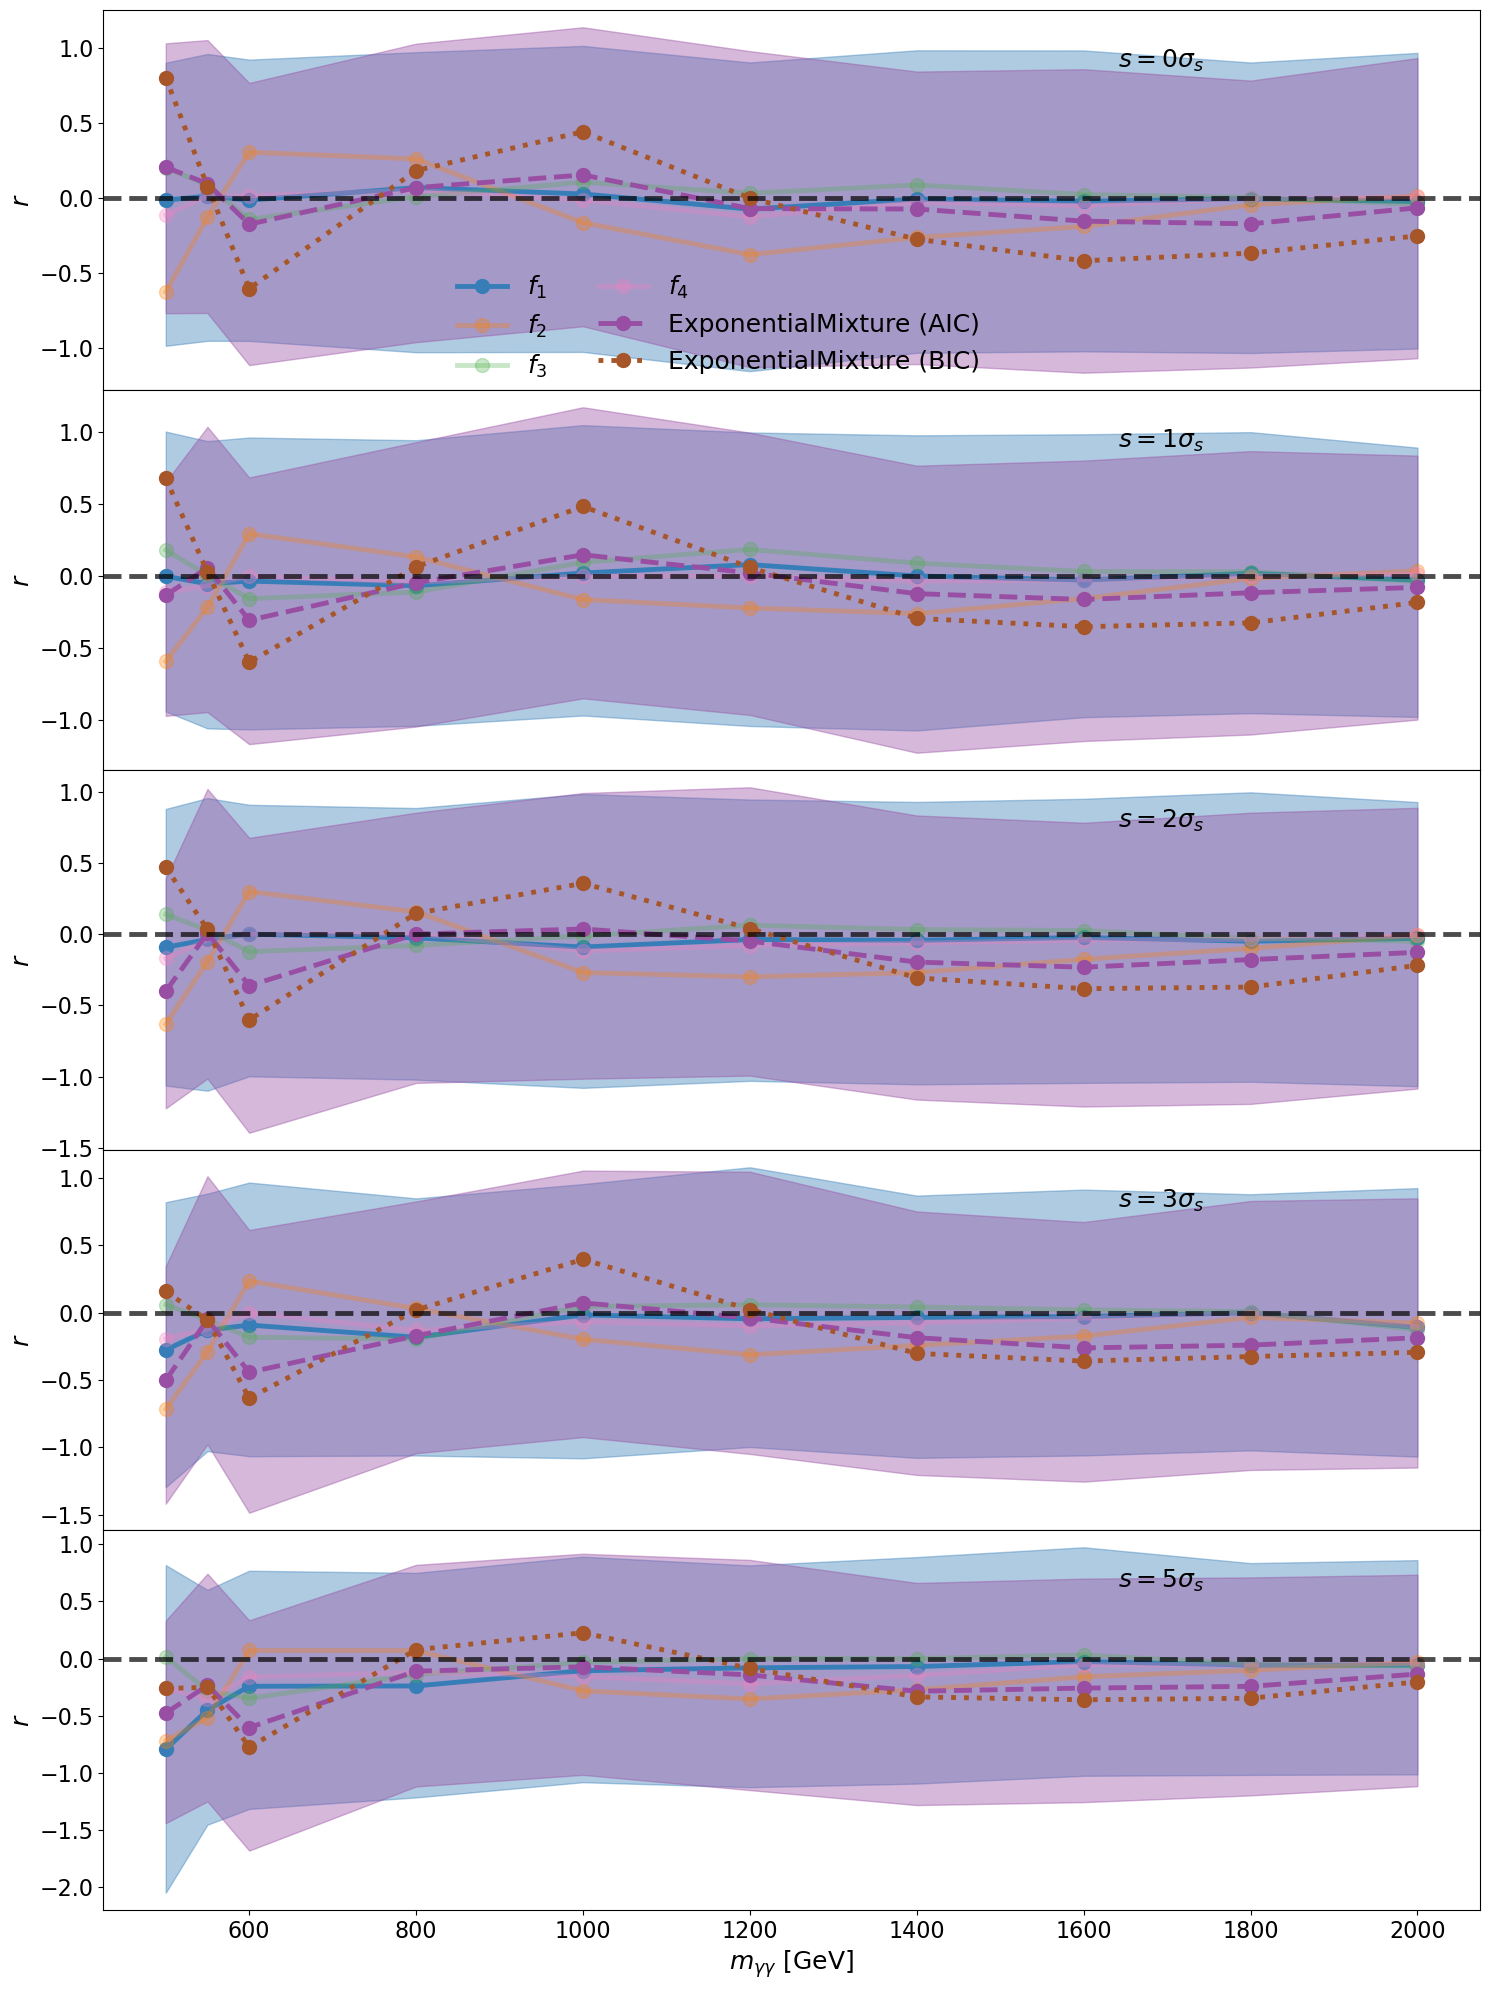

In [9]:
# Plot recovered significance versus injected signal, per background family
fontsize, labelsize, linewidth, markersize = 18, 16, 3.5, 10

colors = {
    "f_1": "#377eb8",
    "f_2": "#ff7f00",
    "f_3": "#4daf4a",
    "f_4": "#f781bf",
    "ExponentialMixture (AIC)": "#984ea3",
    "ExponentialMixture (BIC)": "#a65628",
}
line_styles = {
    "f_1": "solid",
    "f_2": "solid",
    "f_3": "solid",
    "f_4": "solid",
    "ExponentialMixture (AIC)": "dashed",
    "ExponentialMixture (BIC)": "dotted",
}

fig, axs = plt.subplots(
    len(c_values),
    1,
    figsize=(15, 4 * len(c_values)),
    sharex=True,
    gridspec_kw={"hspace": 0},
)
axs = np.atleast_1d(axs)

# Numerical minimization can make the likelihood-ratio argument slightly negative.
likelihood_ratio = 2 * (df["null_nll"] - df["alt_nll"])
metric_magnitude = np.sqrt(np.clip(likelihood_ratio, 0, None))
df["metric"] = np.sign(df["alt_n_sig"] - df["n_inj"]) * metric_magnitude
valid_metric = np.isfinite(df["metric"])

for i_c, c in enumerate(c_values):
    ax = axs[i_c]
    for bkg_model_name in df["bkg_model_name"].unique():
        model_results = df[(df["bkg_model_name"] == bkg_model_name) & valid_metric]

        xs = []
        ys = []
        y_lo = []
        y_hi = []

        for signal_point in signal_points:
            sp_results = model_results[
                (model_results["signal_mean"] == signal_point[0])
                & (model_results["signal_width"] == signal_point[1])
                & (model_results["c"] == c)
            ]
            if sp_results.empty:
                continue

            y_med, y_low, y_high = np.percentile(
                sp_results["metric"].to_numpy(), [50, 16, 84]
            )
            xs.append(signal_point[0])
            ys.append(y_med)
            y_lo.append(y_low)
            y_hi.append(y_high)

        if not xs:
            continue

        label = bkg_model_name if "ExponentialMixture" in bkg_model_name else f"${bkg_model_name}$"
        alpha = 1.0 if bkg_model_name in [toy_model.name, "ExponentialMixture (AIC)", "ExponentialMixture (BIC)"] else 0.3
        ax.plot(
            xs,
            ys,
            label=label,
            color=colors[bkg_model_name],
            linestyle=line_styles[bkg_model_name],
            linewidth=linewidth,
            marker="o",
            markersize=markersize,
            alpha=alpha,
        )
        if bkg_model_name == toy_model.name or bkg_model_name == "ExponentialMixture (AIC)":
            ax.fill_between(xs, y_lo, y_hi, color=colors[bkg_model_name], alpha=0.4)

    ax.axhline(0, color="black", linestyle="--", linewidth=linewidth, alpha=0.7)
    ax.text(
        0.8,
        0.9,
        f"$s = {c} \\sigma_s$",
        transform=ax.transAxes,
        fontsize=fontsize,
        verticalalignment="top",
        horizontalalignment="right",
    )
    ax.set_ylabel("$r$", fontsize=fontsize)
    ax.tick_params(axis="y", labelsize=labelsize)

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, framealpha=0, loc=(0.25, 0), fontsize=fontsize, ncol=2)
axs[-1].set_xlabel("$m_{\\gamma\\gamma}$ [GeV]", fontsize=fontsize)
axs[-1].tick_params(axis="x", labelsize=labelsize)
fig.tight_layout()

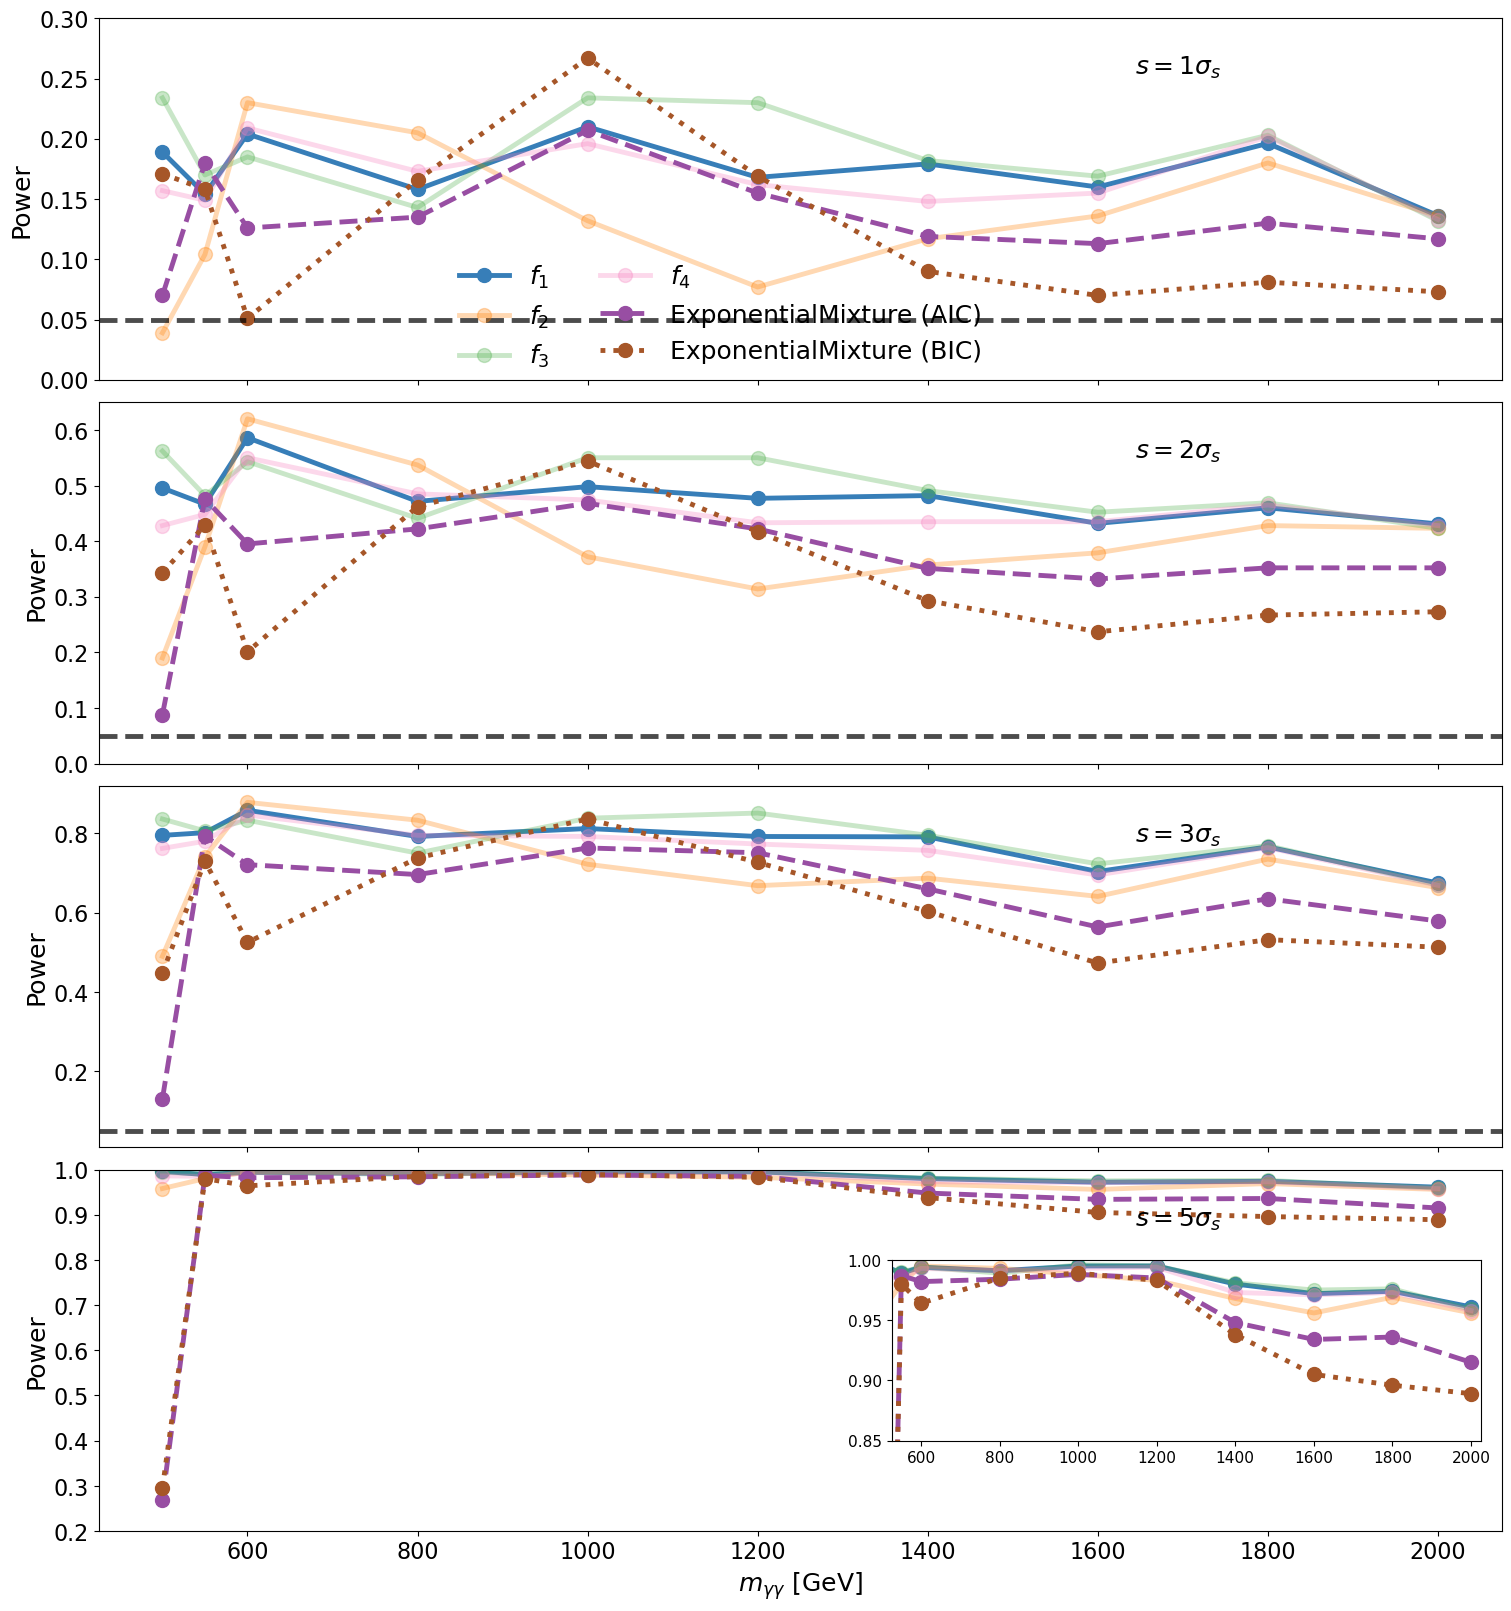

In [10]:
# Plot the pointwise power of the test statistic,
# i.e., the fraction of toys that exceed the 95% background-only quantile.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fontsize, labelsize, linewidth, markersize = 18, 16, 3.5, 10
power_c_values = [c for c in c_values if c != 0]

# The background-only fit is the null hypothesis for this test statistic.
likelihood_ratio = 2 * (df["bkg_only_nll"] - df["alt_nll"])
df["test_statistic"] = np.clip(likelihood_ratio, 0, None)
valid_test_statistic = np.isfinite(df["test_statistic"])

fig, axs = plt.subplots(
    len(power_c_values),
    1,
    figsize=(15, 4 * len(power_c_values)),
    sharex=True,
    gridspec_kw={"hspace": 0},
    layout="constrained",
)
axs = np.atleast_1d(axs)

for i_c, c in enumerate(power_c_values):
    ax = axs[i_c]
    plotted_lines = []
    for bkg_model_name in df["bkg_model_name"].unique():
        model_results = df[
            (df["bkg_model_name"] == bkg_model_name)
            & valid_test_statistic
        ]
        background_results = model_results[model_results["c"] == 0]

        xs = []
        powers = []
        for signal_point in signal_points:
            point_mask = (
                (model_results["signal_mean"] == signal_point[0])
                & (model_results["signal_width"] == signal_point[1])
            )
            background_test_statistic = background_results.loc[
                point_mask, "test_statistic"
            ]
            injected_test_statistic = model_results.loc[
                point_mask & (model_results["c"] == c), "test_statistic"
            ]
            if background_test_statistic.empty or injected_test_statistic.empty:
                continue

            threshold = np.quantile(background_test_statistic, 0.95)
            xs.append(signal_point[0])
            powers.append((injected_test_statistic > threshold).mean())

        if not xs:
            continue

        label = bkg_model_name if "ExponentialMixture" in bkg_model_name else f"${bkg_model_name}$"
        alpha = 1.0 if bkg_model_name in [toy_model.name, "ExponentialMixture (AIC)", "ExponentialMixture (BIC)"] else 0.3
        plot_kwargs = {
            "label": label,
            "color": colors[bkg_model_name],
            "linestyle": line_styles[bkg_model_name],
            "linewidth": linewidth,
            "marker": "o",
            "markersize": markersize,
            "alpha": alpha,
        }
        ax.plot(xs, powers, **plot_kwargs)
        plotted_lines.append((xs, powers, plot_kwargs))

    ax.axhline(0.05, color="black", linestyle="--", linewidth=linewidth, alpha=0.7)
    ax.text(
        0.8,
        0.9,
        f"$s = {c} \\sigma_s$",
        transform=ax.transAxes,
        fontsize=fontsize,
        verticalalignment="top",
        horizontalalignment="right",
    )
    ax.set_ylabel("Power", fontsize=fontsize)
    ax.tick_params(axis="y", labelsize=labelsize)

    if c == 1:
        ax.set_ylim(0, 0.3)
    elif c == 2:
        ax.set_ylim(0, 0.65)
    elif c == 5:
        # Preserve the low-power points while magnifying the near-unity region.
        ax.set_ylim(0.2, 1.0)
        inset = inset_axes(ax, width="42%", height="50%", loc="center right", borderpad=1.5)
        for xs, powers, plot_kwargs in plotted_lines:
            inset.plot(xs, powers, **{key: value for key, value in plot_kwargs.items() if key != "label"})
        inset.set_xlim(525, 2025)
        inset.set_ylim(0.85, 1.0)
        inset.tick_params(axis="both", labelsize=11)

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, framealpha=0, loc=(0.25, 0), fontsize=fontsize, ncol=2)
axs[-1].set_xlabel("$m_{\\gamma\\gamma}$ [GeV]", fontsize=fontsize)
axs[-1].tick_params(axis="x", labelsize=labelsize)